# ZOO（Zeroth Order Optimization）黑盒攻击

ZOO（Chen et al., 2017）通过坐标有限差分估计损失函数梯度，在没有模型参数/梯度的情况下使用 Adam 优化扰动，达到与白盒 C&W 相当的攻击效果。
参考：CAISP 课程模块二对抗攻击章节（ZOO: Chen et al., 2017）。

主要步骤：
1. 定义 C&W 损失 `max(max_wrong_logit - logit_correct + confidence, 0)`；
2. 在低维扰动空间（如 16×16）上用对称差分估计梯度；
3. 使用 Adam 更新扰动；
4. 对常数 `c` 进行二分搜索，平衡攻击成功率与扰动大小。


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# ==============================
# 1. SimpleCNN 模型（输出 logits）
# ==============================
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(32 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

train_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
attack_device = torch.device("cpu")

transform = transforms.Compose([transforms.ToTensor()])
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

model = SimpleCNN().to(train_device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"开始训练 SimpleCNN（使用 {train_device}）...")
for epoch in range(10):
    running_loss = 0.0
    for inputs, labels in trainloader:
        inputs, labels = inputs.to(train_device), labels.to(train_device)
        optimizer.zero_grad()
        logits = model(inputs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch + 1}, Loss: {running_loss / len(trainloader):.4f}")
print("模型训练完成！")

model.to(attack_device)
model.eval()


开始训练 SimpleCNN（使用 cuda）...
Epoch 1, Loss: 1.5789
Epoch 2, Loss: 1.2594
Epoch 3, Loss: 1.1177
Epoch 4, Loss: 1.0139
Epoch 5, Loss: 0.9374
Epoch 6, Loss: 0.8862
Epoch 7, Loss: 0.8362
Epoch 8, Loss: 0.7911
Epoch 9, Loss: 0.7518
Epoch 10, Loss: 0.7143
模型训练完成！


SimpleCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=2048, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

## ZOO 攻击：坐标有限差分 + Adam + 二分搜索

攻击只依赖模型的输出（logits），不依赖反向传播。为了降低查询量，扰动先在低分辨率空间 `r ∈ R^{3×16×16}` 上优化，再通过双线性上采样还原到 32×32。


In [2]:
def cw_loss_tensor(logits, y, confidence=0.0):
    # 标准 C&W 损失：max(max_wrong_logit - logit_correct + confidence, 0)
    correct = logits[0, y]
    others = logits.clone()
    others[0, y] = -1e9
    max_other = others.max()
    return torch.clamp(max_other - correct + confidence, min=0.0)

def zoo_cw_attack(x, y, confidence=0.0, h=1e-3, lr=0.01,
                  max_iter_per_c=100, binary_steps=5, c_init=1e-2,
                  low_res=(3, 16, 16)):
    x = x.to(attack_device)
    y_val = y.item()
    c = c_init
    best_adv = None
    best_l2 = float('inf')
    total_queries = 0

    for b in range(binary_steps):
        # 在低维空间中初始化扰动变量
        r = torch.zeros(low_res, dtype=torch.float32, device=attack_device, requires_grad=False)
        r_param = torch.nn.Parameter(r.clone())
        optimizer = optim.Adam([r_param], lr=lr)

        def loss_fn(r_input):
            delta = F.interpolate(r_input.unsqueeze(0), size=(32, 32), mode='bilinear', align_corners=False)
            x_adv = torch.clamp(x + delta, 0.0, 1.0)
            logits = model(x_adv)
            f = cw_loss_tensor(logits, y_val, confidence)
            l2 = torch.norm(delta) ** 2
            return c * f + l2

        for step in range(max_iter_per_c):
            grad = torch.zeros_like(r_param.data)
            for i in range(r_param.numel()):
                r_plus = r_param.detach().clone()
                r_plus.view(-1)[i] += h
                r_minus = r_param.detach().clone()
                r_minus.view(-1)[i] -= h
                grad.view(-1)[i] = (loss_fn(r_plus) - loss_fn(r_minus)) / (2 * h)
                total_queries += 2
            # 将估计梯度交给 Adam 更新
            r_param.grad = grad
            optimizer.step()

        # 本轮 c 结束后的最终对抗样本
        with torch.no_grad():
            delta = F.interpolate(r_param.unsqueeze(0), size=(32, 32), mode='bilinear', align_corners=False)
            x_adv = torch.clamp(x + delta, 0.0, 1.0)
            logits = model(x_adv)
            pred = logits.argmax(dim=1).item()
            l2 = torch.norm(delta).item()

        if pred != y_val:
            # 成功：尝试更小的 c 以获得更小扰动
            if l2 < best_l2:
                best_l2 = l2
                best_adv = x_adv.clone()
            c = c / 2.0
        else:
            # 失败：增大 c，加强攻击强度
            c = c * 2.0

    success = best_adv is not None
    return best_adv, success, total_queries, best_l2

print("ZOO C&W 攻击函数定义完成。")


ZOO C&W 攻击函数定义完成。


## 攻击 5-10 张测试图片并统计

对随机选取的测试样本运行 ZOO 攻击，报告攻击成功率、成功样本的平均查询次数和平均 L2 扰动，并可视化其中一次成功的攻击。


--- 攻击样本 1, 真实标签 2 ---
成功: False, 查询: 768000, L2扰动: inf, 对抗预测: None
--- 攻击样本 2, 真实标签 7 ---
成功: False, 查询: 768000, L2扰动: inf, 对抗预测: None
--- 攻击样本 3, 真实标签 8 ---
成功: False, 查询: 768000, L2扰动: inf, 对抗预测: None
--- 攻击样本 4, 真实标签 2 ---
成功: True, 查询: 768000, L2扰动: 0.0034, 对抗预测: 6


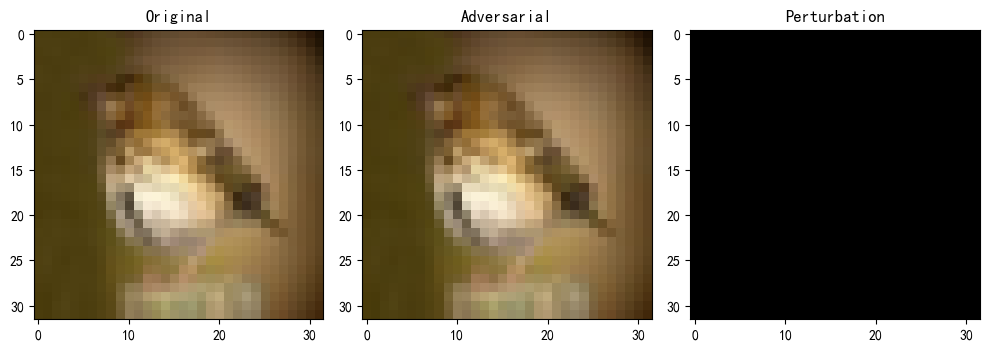

--- 攻击样本 5, 真实标签 9 ---
成功: True, 查询: 768000, L2扰动: 0.0040, 对抗预测: 8


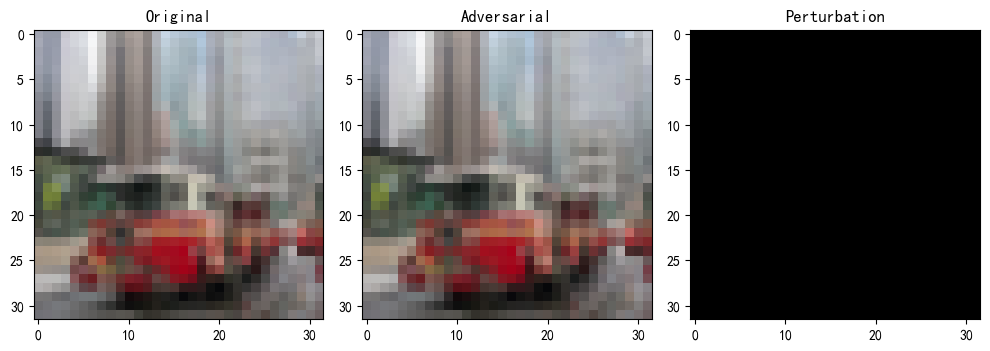


攻击成功率: 40.00%
成功样本平均查询次数: 768000.00
成功样本平均 L2 扰动: 0.0037


In [3]:
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=1, shuffle=True)

def visualize_attack(x, x_adv):
    x_np = x.squeeze(0).permute(1, 2, 0).cpu().numpy()
    x_adv_np = x_adv.squeeze(0).permute(1, 2, 0).cpu().numpy()
    diff = np.abs(x_np - x_adv_np)
    fig, axs = plt.subplots(1, 3, figsize=(10, 5))
    axs[0].imshow(np.clip(x_np, 0, 1))
    axs[0].set_title("Original")
    axs[1].imshow(np.clip(x_adv_np, 0, 1))
    axs[1].set_title("Adversarial")
    axs[2].imshow(diff)
    axs[2].set_title("Perturbation")
    plt.tight_layout()
    plt.show()

num_attacks = 5
successes = 0
queries_success = []
l2_success = []
for i in range(num_attacks):
    x, y = next(iter(testloader))
    x, y = x.to(attack_device), y.to(attack_device)
    print(f"--- 攻击样本 {i + 1}, 真实标签 {y.item()} ---")
    x_adv, success, queries, l2 = zoo_cw_attack(x, y)
    if x_adv is not None:
        pred_adv = model(x_adv).argmax(dim=1).item()
    else:
        pred_adv = None
    print(f"成功: {success}, 查询: {queries}, L2扰动: {l2:.4f}, 对抗预测: {pred_adv}")
    if success:
        successes += 1
        queries_success.append(queries)
        l2_success.append(l2)
        visualize_attack(x, x_adv)

asr = successes / num_attacks * 100
print(f"\n攻击成功率: {asr:.2f}%")
if queries_success:
    print(f"成功样本平均查询次数: {np.mean(queries_success):.2f}")
    print(f"成功样本平均 L2 扰动: {np.mean(l2_success):.4f}")


## 可视化分析：ZOO 查询效率与攻击结果

ZOO 攻击仅依赖模型输出，每次成功攻击都会消耗大量黑盒查询。下面展示成功攻击样本的查询次数分布，以及成功/失败样本的统计。

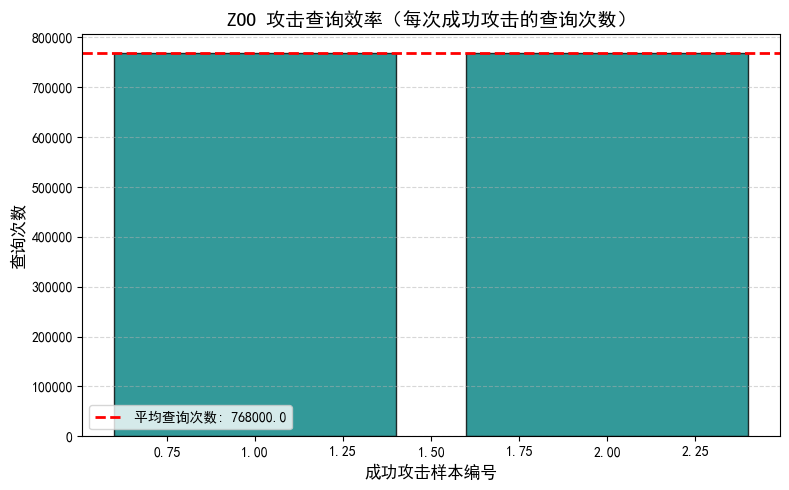

In [4]:
import numpy as np
import matplotlib.pyplot as plt

if queries_success:
    fig, ax = plt.subplots(figsize=(8, 5))
    x = np.arange(1, len(queries_success) + 1)
    ax.bar(x, queries_success, color='teal', edgecolor='black', alpha=0.8)
    avg_q = np.mean(queries_success)
    ax.axhline(avg_q, color='red', linestyle='--', linewidth=2,
               label=f'平均查询次数: {avg_q:.1f}')

    ax.set_xlabel('成功攻击样本编号', fontsize=12)
    ax.set_ylabel('查询次数', fontsize=12)
    ax.set_title('ZOO 攻击查询效率（每次成功攻击的查询次数）', fontsize=14)
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    print('当前没有成功攻击样本，无法绘制查询效率图。')


ZOO 攻击的总体成功与失败比例。

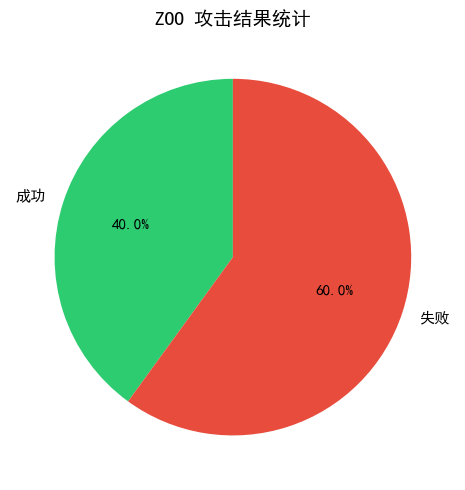

In [5]:
import numpy as np
import matplotlib.pyplot as plt

labels = ['成功', '失败']
counts = [successes, num_attacks - successes]
colors = ['#2ecc71', '#e74c3c']

fig, ax = plt.subplots(figsize=(6, 5))
ax.pie(counts, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90,
       textprops={'fontsize': 11})
ax.set_title('ZOO 攻击结果统计', fontsize=14)
plt.tight_layout()
plt.show()


## 结论

ZOO 通过坐标有限差分估计梯度，并结合 Adam 与 C&W 二分搜索，在仅依赖模型输出的情况下实现白盒级别的攻击性能。
虽然每轮需要大量黑盒查询，但通过低维扰动空间（resize 到 16×16）可以显著降低查询开销，体现了查询效率与攻击成功率之间的典型权衡。
